# Repaso final: Turismo internacional

Este repaso usa un contexto distinto al examen, pero practica los mismos patrones: recorrer datos, crear una función, filtrar, agrupar, ordenar, graficar e interpretar.

Trabaje con `turismo_internacional_repaso.csv` sin modificarlo. **Antes de iniciar, guarde una copia como `Apellido_Nombre_Repaso_Final.ipynb`.**

Distribución inequívoca: Parte 1, Parte 2, Parte 3, Parte 4, Parte 5 y cierre.

## Parte 1 — Preparación

**TODO 1.1 — Entrada, proceso y salida**

Escriba aquí una frase que identifique: (1) la entrada —el archivo y sus datos—, (2) el proceso —las operaciones de análisis— y (3) la salida —tablas, gráficos e interpretaciones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

archivo = 'turismo_internacional_repaso.csv'
df = pd.read_csv(archivo)
df.head()

,pais,anio,llegadas_miles
0,Belize,2012,1028.0
1,Belize,2013,1022.0
2,Belize,2014,1289.0
3,Belize,2015,1299.0
4,Belize,2016,1391.0


In [5]:
print("Dimensiones:", df.shape)
print("Tipado:", df.info())

print("Cantidad de valores nulos:\n", df.isnull().sum())

Dimensiones: (94, 3)
<class 'pandas.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pais            94 non-null     str    
 1   anio            94 non-null     int64  
 2   llegadas_miles  94 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 2.3 KB
Tipado: None
Cantidad de valores nulos:
 pais              0
anio              0
llegadas_miles    0
dtype: int64


## Parte 2 — Python base: registros y función

1. Muestre `shape`, `dtypes` y una descripción breve de cada columna.
2. Convierta el DataFrame en una lista de diccionarios llamada `registros`.
3. Con un ciclo y una condición, cuente los registros cuya cantidad de llegadas es mayor a 3 000 miles.
4. Complete `resumen_pais`. Debe devolver un diccionario con país, cantidad de años, total y promedio de llegadas para el país solicitado. Si no existe, debe devolver `None`.

In [ ]:
# Escriba su solución aquí. [CONTADOR]
registros = df.to_dict(orient='records')
contador = 0

for registro in registros:
    if registro["llegadas_miles"] > 3000:
        contador += 1
print(f"Registros con más de 3000 visitantes: {contador}")

Registros con más de 3000 visitantes: 26


In [26]:
def resumen_pais(registros, pais):
    # Recorra los registros y acumule solo los del país indicado.
    total = 0
    cantidad_anios = 0
    
    for registro in registros:
        if registro["pais"] == pais:
            total += registro["llegadas_miles"]
            cantidad_anios += 1

    if cantidad_anios == 0:
        print(f"No se encontraron registros para {pais}")
        return None

    promedio = total / cantidad_anios
    return {
        "pais": pais,
        "cantidad_anios": cantidad_anios,
        "total_llegadas": total,
        "promedio_llegadas": promedio
    }

# Pruebe la función con 'Costa Rica' y con un país inexistente.
print(resumen_pais(registros, "Costa Rica"))
print(resumen_pais(registros, "México"))

{'pais': 'Costa Rica', 'cantidad_anios': 9, 'total_llegadas': 25102.5, 'promedio_llegadas': 2789.1666666666665}
No se encontraron registros para México
None


## Parte 3 — Pandas: Análisis Comparativo y de Impacto

Con el nuevo conjunto de datos, podemos realizar un análisis regional más profundo.

1.  **Ranking de Líderes Regionales:**
    *   Calcula el **total de llegadas por país** para todo el período (2012-2022).
    *   Genera un ranking ordenado de mayor a menor para identificar los 3 países con más llegadas en la región.

2.  **Análisis de Impacto (COVID-19):**
    *   Crea un nuevo DataFrame que contenga únicamente los datos de 2019 y 2020.
    *   A partir de él, calcula la **caída porcentual** en el turismo para cada país. La fórmula es `((llegadas_2019 - llegadas_2020) / llegadas_2019) * 100`.
    *   Muestra una tabla con los resultados, ordenada de mayor a menor caída porcentual, para ver qué países fueron los más afectados.

In [ ]:
# Escriba sus filtros, cálculos, tabla resumen y ranking aquí.
top_3 = df.groupby('pais')['llegadas_miles'].sum().nlargest(3) # AGRUPA LOS PAÍSES DE LA TABLA Y ADEMÁS, SE LE PASA UNA COLUMNA
print("Top 3 de llegadas totales 2012-2022:")
top_3
# Recuerde usar paréntesis para combinar condiciones y nlargest(5, 'llegadas_miles').

Top 3 de llegadas totales 2012-2022:


pais
Mexico      762253.0
Colombia     33974.0
Perú         32571.0
Name: llegadas_miles, dtype: float64

In [46]:
# DT solo con los datos de 2019 y 2020
# calcular la caida porcentual del turismo por pais
# mostrar una tabla con los resultados y ordenar de mayor a menor caida porcentual 

columna_2019 = df[df['anio'] == 2019][['pais', 'llegadas_miles']].set_index('pais').nlargest(5, 'llegadas_miles')
columna_2020 = df[df['anio'] == 2020][['pais', 'llegadas_miles']].set_index('pais').nlargest(5, 'llegadas_miles')
caida_porcentual = ((columna_2019 - columna_2020) / columna_2019) * 100

print("Caída porcentual del turismo por país en época de COVID-19 (2019-2020):")
caida_porcentual.sort_values(by='llegadas_miles', ascending=False).round(2)


Caída porcentual del turismo por país en época de COVID-19 (2019-2020):


,llegadas_miles
pais,
Perú,79.48
El Salvador,73.21
Colombia,67.71
Costa Rica,65.94
Mexico,47.51


In [42]:
df_2019 = (df[df["anio"] == 2019].set_index('pais')['llegadas_miles'])
df_2020 = (df[df["anio"] == 2020].set_index('pais')['llegadas_miles'])

df_impacto = pd.DataFrame({
    '2019': df_2019,
    '2020': df_2020
})

df_impacto['caida_porcentual'] = ((df_impacto['2019'] - df_impacto ['2020']) / df_impacto['2019']) * 100

display(df_impacto.sort_values(by='caida_porcentual', ascending= False))

,2019,2020,caida_porcentual
pais,,,
Perú,4372.0,897.0,79.483074
Guatemala,2560.0,594.0,76.796875
Panama,2494.0,647.0,74.057739
El Salvador,2639.0,707.0,73.209549
Honduras,2315.0,669.0,71.101512
Belize,1674.0,487.0,70.908005
Colombia,4332.0,1399.0,67.705448
Nicaragua,1455.0,474.0,67.422680
Costa Rica,3366.0,1146.5,65.938800


## Parte 4 — Visualización Comparativa e Interpretación

Ahora, vamos a contar la historia de los datos con visualizaciones más ricas.

1.  **Gráfico de Líneas Comparativo:**
    *   Construye una gráfica de líneas que compare la evolución de llegadas para **todos los países** a lo largo de los años.
    *   **Interpretación:** Tu análisis debe mencionar: (1) La escala de México en comparación con los demás, (2) la tendencia general antes de 2020, y (3) el impacto visible de la pandemia en 2020 en todo el grupo.

2.  **Gráfico de Barras del Impacto (COVID-19):**
    *   Crea un **gráfico de barras horizontales** que muestre la **caída porcentual** por país que calculaste en la Parte 3.
    *   **Interpretación:** Explica qué países sufrieron el mayor y menor impacto relativo según la gráfica.

3.  **Gráfico de Barras de Recuperación:**
    *   Crea un **gráfico de barras agrupadas** que compare las llegadas de **2019 (pre-pandemia)** con las de **2022 (recuperación)** para cada país.
    *   **Interpretación:** Describe qué países parecen haberse recuperado más rápido y si alguno ha superado sus niveles pre-pandemia.

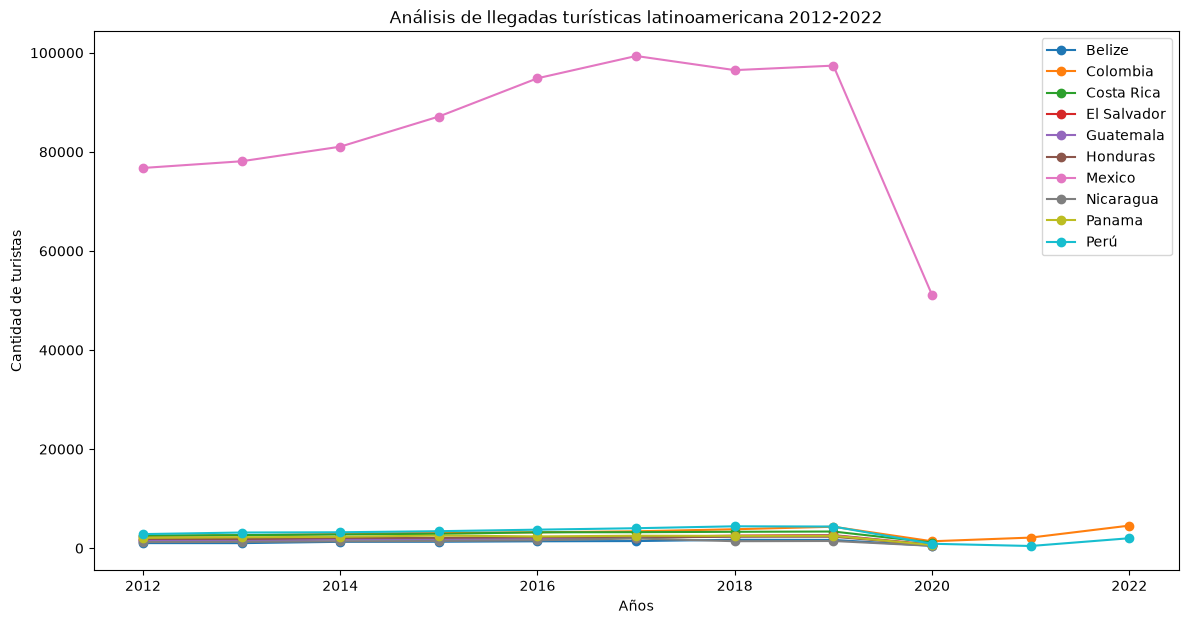

In [ ]:
# Escriba aquí la primer gráfica.
# Use plt.show() al finalizar cada una e incluya una interpretación escrita.

plt.figure(figsize=(14, 7))

for pais, datos_pais in df.groupby('pais'):
    eje_x = datos_pais['anio']
    eje_y = datos_pais['llegadas_miles']
    #display(pais, datos_pais['anio'], ":", datos_pais['llegadas_miles'])
    plt.plot(eje_x, eje_y, marker='o', label=pais)
    
#plt.ylim(1000, 5000) # Limitar los datos
plt.title('Análisis de llegadas turísticas latinoamericana 2012-2022')
plt.xlabel('Año')
plt.ylabel('Cantidad de turistas')
plt.legend()
plt.show()

In [71]:
df_impacto

,2019,2020,caida_porcentual
pais,,,
Belize,1674.0,487.0,70.908005
Costa Rica,3366.0,1146.5,65.938800
El Salvador,2639.0,707.0,73.209549
Guatemala,2560.0,594.0,76.796875
Honduras,2315.0,669.0,71.101512
Mexico,97406.0,51128.0,47.510420
Nicaragua,1455.0,474.0,67.422680
Panama,2494.0,647.0,74.057739
Colombia,4332.0,1399.0,67.705448


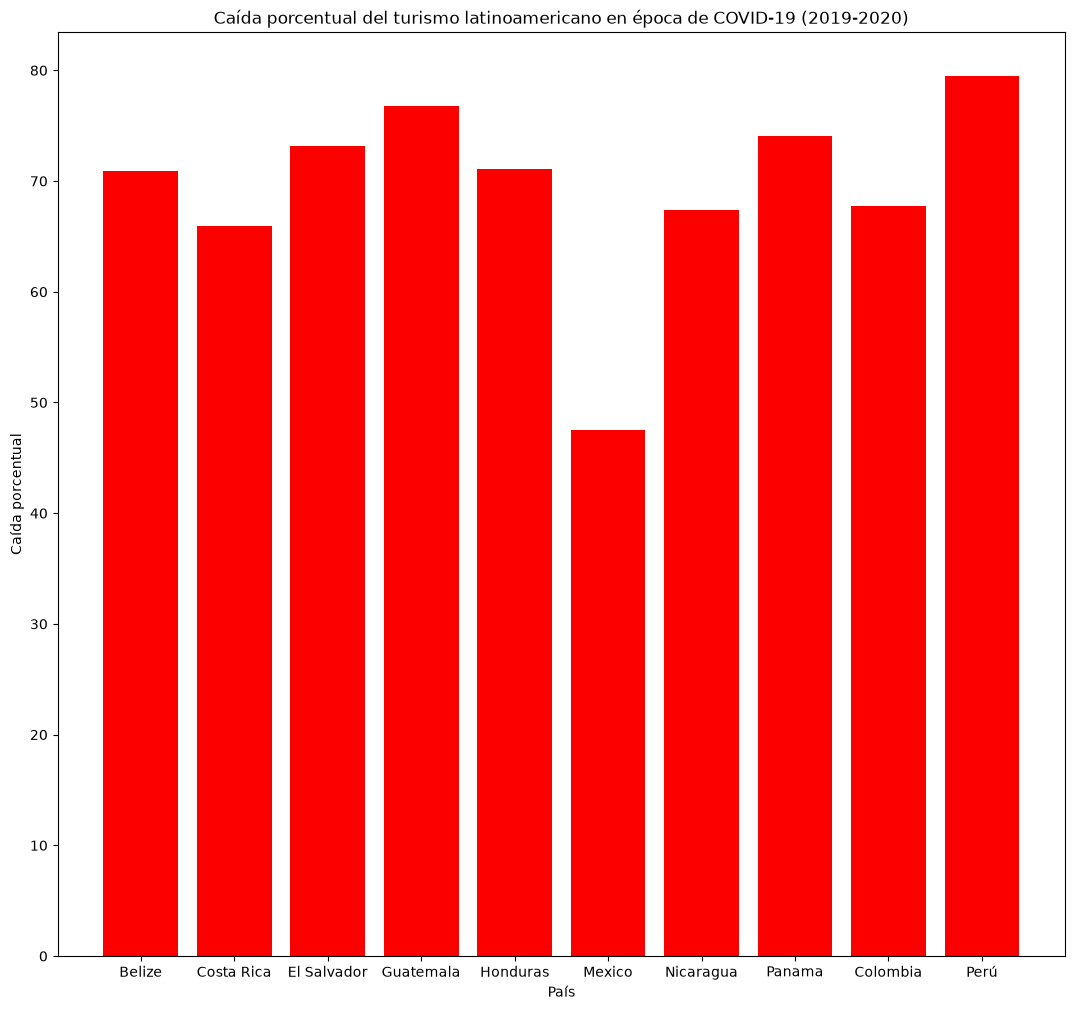

In [ ]:
# Escriba aquí la segunda gráfica.
plt.figure(figsize=(13, 12))

barras = plt.bar(df_impacto.index, df_impacto['caida_porcentual'], color="#FC0000")

plt.title('Caída porcentual del turismo latinoamericano en época de COVID-19 (2019-2020)')
plt.xlabel('País')
plt.ylabel('Caída porcentual')
plt.show()

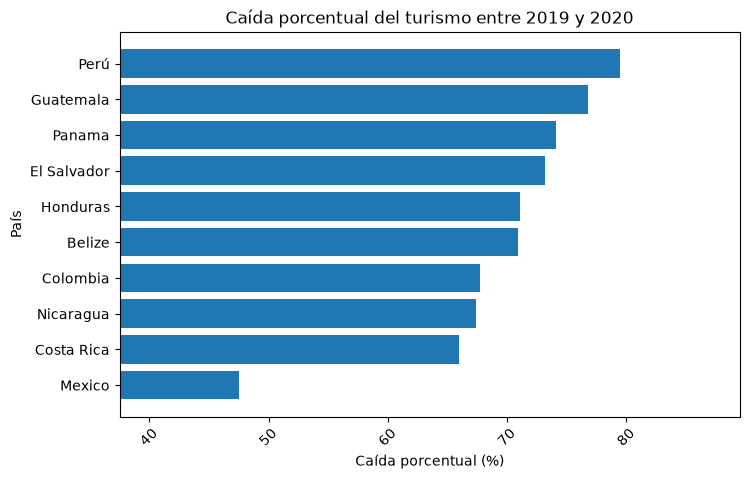

In [ ]:
# Ejemplo de profesor
# Ordenar 
df_impacto = df_impacto.sort_values("caida_porcentual")


# Gráfico de barras horizontales
plt.figure(figsize=(8, 5))
plt.barh(df_impacto.index, df_impacto["caida_porcentual"])


plt.title("Caída porcentual del turismo entre 2019 y 2020")
plt.xlabel("Caída porcentual (%)")
plt.ylabel("País")
plt.xticks(rotation=45)


minimo = df_impacto["caida_porcentual"].min() - 10
maximo = df_impacto["caida_porcentual"].max() + 10
plt.xlim(minimo, maximo)


plt.show()

In [ ]:
# Escriba aquí la tercer gráfica.
df_2019 = df[df["anio"] == 2019].set_index('pais')['llegadas_miles']

## Parte 5 — Mini-simulacro individual

Sin consultar soluciones, resuelva lo siguiente:

1. Convierta el DataFrame a una lista de diccionarios y cree una función que recorra los registros, use una condición y devuelva el total de llegadas de un país indicado; devuelva `None` si no existe.
2. Use un filtro compuesto para seleccionar registros de 2019 o posteriores con más de 3 000 miles de llegadas.
3. Cree un resumen con `groupby(...).agg(...)` y seleccione con `nlargest(5, 'llegadas_miles')` las cinco observaciones de mayor valor.
4. Elabore una gráfica de barras horizontales del ranking y redacte un hallazgo numérico verificable, una interpretación y una limitación del dataset.

**Autoevaluación:** ¿su respuesta incluye lista de diccionarios, ciclo, condición y función?, ¿sus filtros usan la columna correcta?, ¿aplicó `groupby(...).agg(...)` y `nlargest(5, ...)`?, ¿sus gráficos son legibles?, ¿sus afirmaciones tienen evidencia y una limitación?

In [5]:
# Resuelva aquí el mini-simulacro.
# Incluya la función, el filtro compuesto, groupby(...).agg(...), nlargest(5, ...)
# y su interpretación con evidencia y limitación.

## Cierre y autoevaluación

Compare su trabajo con la lista de autoevaluación de la Parte 5. Entregue el notebook con su nombre, código ejecutado, tres gráficos, interpretaciones con evidencia y una limitación. La retroalimentación docente se realiza después del intento individual.